# Решение одномерного уравнения теплопроводности

Шубина София Антновна НПИбд-02-23 студ.билет: 1132232885

Основное уравнение:

$$ \frac{\partial u}{\partial t} = a^2 \frac{\partial^2 u}{\partial x^2} $$

где:
- $u(x,t)$ — температура
- $x$ — координата
- $t$ — время
- $a$ — коэффициент температуропроводности


## Метод разделения переменных

Предполагаем решение в виде:

$$u(x,t) = X(x)T(t)$$

После подстановки получаем два обыкновенных дифференциальных уравнения:

Пространственное:
$$X'' + \lambda X = 0$$

Временное:
$$T' + a^2\lambda T = 0$$


In [3]:
import sympy as sp

x, t = sp.symbols('x t')
a = sp.symbols('a', positive=True)

u = sp.Function('u')(x, t)

heat_eq = sp.Eq(sp.diff(u, t), a**2 * sp.diff(u, x, 2))

print('Уравнение теплопроводности:')
sp.pprint(heat_eq)


Уравнение теплопроводности:
                  2          
∂              2 ∂           
──(u(x, t)) = a ⋅───(u(x, t))
∂t                 2         
                 ∂x          


## Подстановка решения $u(x,t)=X(x)T(t)$

In [4]:
X = sp.Function('X')(x)
T = sp.Function('T')(t)

u_sep = X*T

lhs = sp.diff(u_sep, t)
rhs = a**2 * sp.diff(u_sep, x, 2)

sep_eq = sp.Eq(lhs, rhs)

print('После подстановки:')
sp.pprint(sep_eq)


После подстановки:
                         2       
     d           2      d        
X(x)⋅──(T(t)) = a ⋅T(t)⋅───(X(x))
     dt                   2      
                        dx       


## Разделение переменных

In [5]:
sep_form = sp.simplify(lhs/(X*T) - rhs/(X*T))

print('Разделение переменных:')
sp.pprint(sep_form)


Разделение переменных:
      2                  
   2 d                   
  a ⋅───(X(x))   d       
       2         ──(T(t))
     dx          dt      
- ──────────── + ────────
      X(x)         T(t)  


## Получение двух ОДУ

In [6]:
lam = sp.symbols('lambda')

ode_space = sp.Eq(sp.diff(X, x, 2) + lam*X, 0)
ode_time = sp.Eq(sp.diff(T, t) + a**2*lam*T, 0)

print('Пространственное уравнение:')
sp.pprint(ode_space)

print('Временное уравнение:')
sp.pprint(ode_time)


Пространственное уравнение:
          2           
         d            
λ⋅X(x) + ───(X(x)) = 0
           2          
         dx           
Временное уравнение:
 2          d           
a ⋅λ⋅T(t) + ──(T(t)) = 0
            dt          


## Решение уравнений

In [7]:
X_sol = sp.dsolve(ode_space)
T_sol = sp.dsolve(ode_time)

print('Решение пространственного уравнения:')
sp.pprint(X_sol)

print('Решение временного уравнения:')
sp.pprint(T_sol)


Решение пространственного уравнения:
                ____           ____
           -x⋅╲╱ -λ        x⋅╲╱ -λ 
X(x) = C₁⋅ℯ          + C₂⋅ℯ        
Решение временного уравнения:
             2    
           -a ⋅λ⋅t
T(t) = C₁⋅ℯ       


## Учет краевых условий (исправление)

Краевые условия:
$$u(0,t)=0, \quad u(L,t)=0$$

С учетом $u(x,t)=X(x)T(t)$ получаем:
$$X(0)=0, \quad X(L)=0$$


## Собственные значения и функции

Решая задачу Штурма–Лиувилля:
$$X'' + \lambda X = 0$$

получаем:
$$X_n(x)=\sin\left(\frac{n\pi x}{L}\right), \quad \lambda_n=\left(\frac{n\pi}{L}\right)^2$$

## Коэффициенты Фурье (исправление)

Используем начальное условие:
$$u(x,0)=f(x)$$

Тогда:
$$A_n=\frac{2}{L}\int_0^L f(x)\sin\left(\frac{n\pi x}{L}\right)dx$$

In [8]:
import sympy as sp
x, L, n = sp.symbols('x L n', positive=True)
f = sp.sin(sp.pi*x/L)
A_n = (2/L)*sp.integrate(f*sp.sin(n*sp.pi*x/L), (x,0,L))
sp.simplify(A_n)

Piecewise((-2*sin(pi*n)/(pi*(n**2 - 1)), (n > 1) | (n < 1)), (1, True))

## Итог

Общее решение одномерного уравнения теплопроводности:

$$u(x,t)=\sum_{n=1}^{\infty} A_n e^{-a^2 (n\pi/L)^2 t} \sin(n\pi x/L)$$

Это решение описывает процесс выравнивания температуры со временем.

<font color="red">**Комментарий:**</font>

Далее используем начальное условие $$u(x,0)=f(x)$$ выведите формулу для $A_n$ с помощью коэффициенов Фурье.
Вы получите в символьном виде формулу для общего решение и его коэффициентов. 

На основе этих формул можно будем искать решения для конкретных примеров. 

## Определение коэффициентов Фурье и общее решение

После нахождения собственных функций и значений общее решение уравнения теплопроводности имеет вид:

$$
u(x,t)=
\sum_{n=1}^{\infty}
A_n
e^{-a^2\left(\frac{n\pi}{L}\right)^2 t}
\sin\left(\frac{n\pi x}{L}\right)
$$

### Использование начального условия

Используем начальное условие:

$$
u(x,0)=f(x)
$$

Подставляя $t=0$ в общее решение, получаем:

$$
f(x)=
\sum_{n=1}^{\infty}
A_n
\sin\left(\frac{n\pi x}{L}\right)
$$

Таким образом, функция $f(x)$ представляется в виде ряда Фурье по системе собственных функций.

### Вывод формулы для коэффициентов $A_n$

Для нахождения коэффициентов воспользуемся ортогональностью синус-функций:

$$
\int_0^L
\sin\left(\frac{n\pi x}{L}\right)
\sin\left(\frac{m\pi x}{L}\right)\,dx
=
\begin{cases}
0, & n \ne m \\
\frac{L}{2}, & n = m
\end{cases}
$$

Умножим обе части разложения на 
$\sin\left(\frac{m\pi x}{L}\right)$ и проинтегрируем по $[0,L]$:

$$
\int_0^L f(x)\sin\left(\frac{m\pi x}{L}\right)\,dx
=
\sum_{n=1}^{\infty}
A_n
\int_0^L
\sin\left(\frac{n\pi x}{L}\right)
\sin\left(\frac{m\pi x}{L}\right)\,dx
$$

В силу ортогональности остается только один член суммы:

$$
\int_0^L f(x)\sin\left(\frac{m\pi x}{L}\right)\,dx
=
A_m \cdot \frac{L}{2}
$$

Отсюда получаем формулу для коэффициентов:

$$
A_n=
\frac{2}{L}
\int_0^L
f(x)\sin\left(\frac{n\pi x}{L}\right)\,dx
$$

### Итоговое решение задачи

Подставляя найденные коэффициенты $A_n$ в общее решение, получаем аналитическое решение задачи теплопроводности:

$$
u(x,t)=
\sum_{n=1}^{\infty}
\left(
\frac{2}{L}
\int_0^L
f(x)\sin\left(\frac{n\pi x}{L}\right)\,dx
\right)
e^{-a^2\left(\frac{n\pi}{L}\right)^2 t}
\sin\left(\frac{n\pi x}{L}\right)
$$


Таким образом, задача сведена к вычислению коэффициентов Фурье функции начального распределения температуры $f(x)$, что позволяет находить решения для конкретных случаев.

<font color="blue">**Задача:**</font>

Постройте распределение температуры для изолированного стального стержня длины $L=1$, теплопроводность $\lambda=40$, плотность $\rho=7700$, теплоёмкость $c=460$ с начальными условиями: $$u(0,t)=0,  u(L,t)=0,$$ $$u(x,0)=sin(\pi \frac{x}{L})$$ при различных t.

## Построение распределения температуры

Рассмотрим задачу теплопроводности для стального стержня длины $L=1$:

$$
\frac{\partial u}{\partial t} = a^2 \frac{\partial^2 u}{\partial x^2}
$$

с краевыми условиями:

$$
u(0,t)=0, \quad u(L,t)=0
$$

и начальным условием:

$$
u(x,0)=\sin\left(\pi \frac{x}{L}\right)
$$

### Физические параметры

- длина стержня: $L=1$
- теплопроводность: $\lambda = 40$
- плотность: $\rho = 7700$
- теплоёмкость: $c = 460$

Коэффициент температуропроводности:

$$
a^2 = \frac{\lambda}{\rho c}
$$

### Аналитическое решение

Так как начальное условие совпадает с первой собственной функцией, решение имеет вид:

$$
u(x,t)=
\sin\left(\frac{\pi x}{L}\right)
e^{-a^2\left(\frac{\pi}{L}\right)^2 t}
$$

При $L=1$:

$$
u(x,t)=
\sin(\pi x)\, e^{-a^2 \pi^2 t}
$$

### Численная реализация и построение графиков

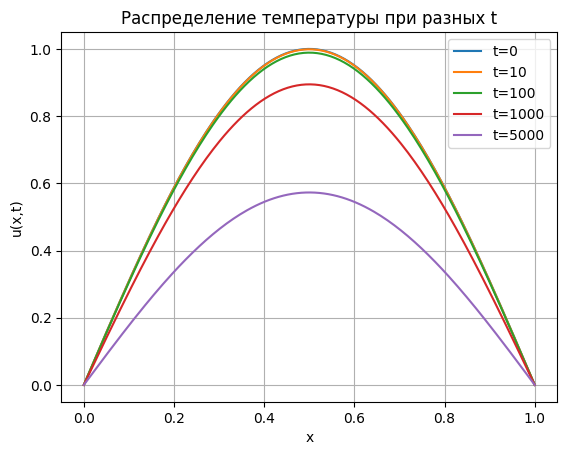

In [9]:
import numpy as np
import matplotlib.pyplot as plt

L = 1
lam = 40
rho = 7700
c = 460

a2 = lam / (rho * c)

x = np.linspace(0, L, 200)

def u(x, t):
    return np.sin(np.pi * x) * np.exp(-a2 * np.pi**2 * t)

# ВАЖНО: берем разные масштабы времени
times = [0, 10, 100, 1000, 5000]

plt.figure()

for t in times:
    plt.plot(x, u(x, t), label=f"t={t}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Распределение температуры при разных t")
plt.legend()
plt.grid()

plt.show()

### Анализ результатов

Полученные графики показывают, что:

- начальное распределение температуры имеет синусоидальную форму;
- со временем амплитуда уменьшается;
- температура стремится к нулю при $t \to \infty$;
- форма распределения сохраняется, изменяется только масштаб.

Это соответствует физическому процессу остывания стержня.

## Почему в решении остается только первый член ряда

Общее решение имеет вид:

$$
u(x,t)=
\sum_{n=1}^{\infty}
A_n e^{-a^2\left(\frac{n\pi}{L}\right)^2 t}
\sin\left(\frac{n\pi x}{L}\right)
$$

Начальное условие:

$$
u(x,0)=\sin\left(\frac{\pi x}{L}\right)
$$

Это уже является одной из собственных функций задачи при $n=1$.

Коэффициенты Фурье:

$$
A_n=\frac{2}{L}\int_0^L
\sin\left(\frac{\pi x}{L}\right)
\sin\left(\frac{n\pi x}{L}\right)dx
$$

В силу ортогональности синусов:

$$
A_1 = 1, \quad A_n = 0 \ (n \ne 1)
$$

Таким образом, в разложении присутствует только один член ряда.


### Физический смысл

Начальное распределение совпадает с собственной формой колебаний стержня, поэтому:

- система не разлагается на несколько мод
- происходит затухание только одной гармоники

Это упрощает решение и приводит к однородному затуханию формы.

## задача 

На концах стержня поддерживается постоянная температура в 100 градусов, при этом начальная температура равна 20.
u(0,t)=100
u(L,t)=100
u(x,0)=20

## Приведение к однородным краевым условиям

Введем новую функцию:

$$
v(x,t)=u(x,t)-100
$$

Тогда:

$$
v(0,t)=0, \quad v(L,t)=0
$$

Начальное условие:

$$
v(x,0)=20-100=-80
$$

## Аналитическое решение

Решение ищется в виде ряда:

$$
v(x,t)=
\sum_{n=1}^{\infty}
B_n e^{-a^2\left(\frac{n\pi}{L}\right)^2 t}
\sin\left(\frac{n\pi x}{L}\right)
$$

Коэффициенты:

$$
B_n=\frac{2}{L}\int_0^L (-80)\sin\left(\frac{n\pi x}{L}\right)dx
$$

Вычисляя интеграл, получаем:

$$
B_n = \frac{-160}{n\pi}(1 - (-1)^n)
$$

Следовательно:

- для четных $n$: $B_n=0$
- для нечетных $n$: $B_n \neq 0$

### Итоговое решение

$$
u(x,t)=100+
\sum_{n=1,3,5,...}
\frac{-320}{n\pi}
e^{-a^2\left(\frac{n\pi}{L}\right)^2 t}
\sin\left(\frac{n\pi x}{L}\right)
$$

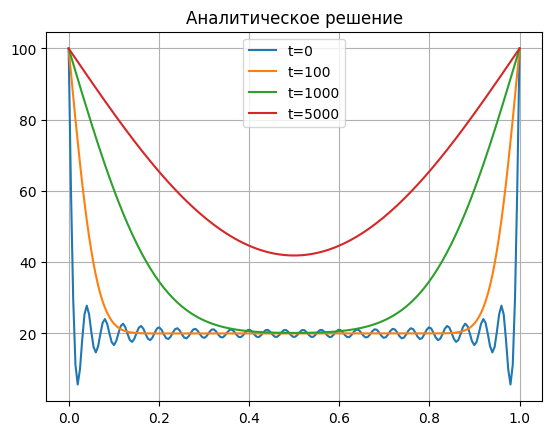

In [41]:
import numpy as np
import matplotlib.pyplot as plt

L = 1
a2 = 40 / (7700 * 460)

x = np.linspace(0, L, 200)

def solution(x, t, N=50):
    s = np.zeros_like(x)
    for n in range(1, N, 2):  # только нечетные
        Bn = -320 / (n * np.pi)
        s += Bn * np.exp(-a2 * (n*np.pi/L)**2 * t) * np.sin(n*np.pi*x/L)
    return 100 + s

times = [0, 100, 1000, 5000]

plt.figure()
for t in times:
    plt.plot(x, solution(x, t), label=f"t={t}")

plt.legend()
plt.grid()
plt.title("Аналитическое решение")
plt.show()

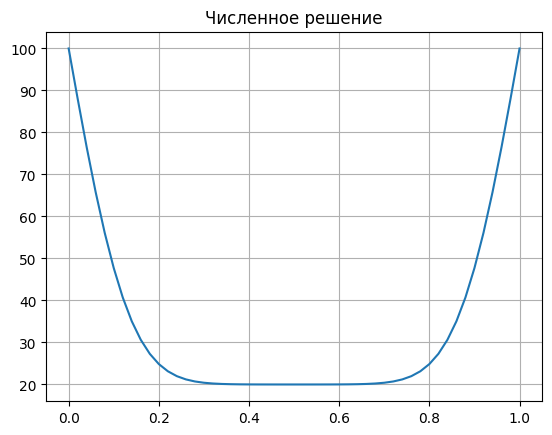

In [42]:
# Численный метод (Самарский)
# явная схема

Nx = 50
Nt = 5000

dx = L / Nx
dt = 0.1

r = a2 * dt / dx**2

u = np.ones(Nx+1)*20
u[0] = 100
u[-1] = 100

for n in range(Nt):
    u_new = u.copy()
    for i in range(1, Nx):
        u_new[i] = u[i] + r*(u[i+1] - 2*u[i] + u[i-1])
    u = u_new

plt.plot(np.linspace(0,L,Nx+1), u)
plt.title("Численное решение")
plt.grid()
plt.show()

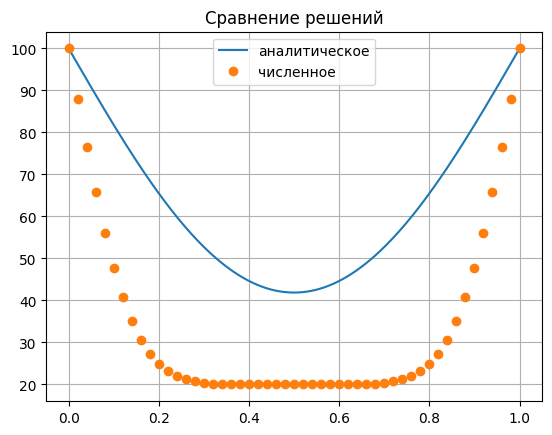

In [43]:
# сравнение
x_num = np.linspace(0, L, Nx+1)

plt.plot(x, solution(x, 5000), label="аналитическое")
plt.plot(x_num, u, 'o', label="численное")

plt.legend()
plt.grid()
plt.title("Сравнение решений")
plt.show()


## Осцилляции при $t=0$

При $t=0$ решение представляется в виде конечной суммы ряда Фурье:

$$
u(x,0) \approx \sum_{n=1}^{N} B_n \sin\left(\frac{n\pi x}{L}\right)
$$

Так как используется конечное число членов $N$, возникает погрешность аппроксимации.

В частности:

- начальное условие $u(x,0)=20$ не удовлетворяет краевым условиям $u(0,t)=u(L,t)=100$;
- после замены $v(x,t)=u(x,t)-100$ получаем разрыв:
  
$$
v(x,0)=-80
$$

- ряд Фурье аппроксимирует разрывную функцию;
- это приводит к появлению осцилляций (эффект Гиббса).



# Двумерное уравнение теплопроводности

Рассмотрим уравнение теплопроводности в двумерном случае:

$$
\frac{\partial u}{\partial t} =
a^2 \left(
\frac{\partial^2 u}{\partial x^2} +
\frac{\partial^2 u}{\partial y^2}
\right)
$$

в области:

$$
0 < x < L, \quad 0 < y < M
$$

с краевыми условиями:

$$
u(0,y,t)=0,\quad u(L,y,t)=0
$$

$$
u(x,0,t)=0,\quad u(x,M,t)=0
$$

и начальным условием:

$$
u(x,y,0)=f(x,y)
$$


## Метод разделения переменных

Ищем решение в виде:

$$
u(x,y,t)=X(x)Y(y)T(t)
$$

Подставим в уравнение:

$$
X Y T' = a^2 (X'' Y T + X Y'' T)
$$

Разделим переменные:

$$
\frac{T'}{a^2 T} =
\frac{X''}{X} + \frac{Y''}{Y}
$$

Введем разделение:

$$
\frac{X''}{X} = -\lambda, \quad \frac{Y''}{Y} = -\mu
$$

Тогда:

$$
\frac{T'}{a^2 T} = -(\lambda + \mu)
$$


## Получаем систему ОДУ

### По x:

$$
X'' + \lambda X = 0
$$

$$
X(0)=0,\quad X(L)=0
$$


### По y:

$$
Y'' + \mu Y = 0
$$

$$
Y(0)=0,\quad Y(M)=0
$$


### По времени:

$$
T' + a^2(\lambda+\mu)T = 0
$$


## Решения

Собственные значения:

$$
\lambda_n = \left(\frac{n\pi}{L}\right)^2
$$

$$
\mu_m = \left(\frac{m\pi}{M}\right)^2
$$

Собственные функции:

$$
X_n(x)=\sin\left(\frac{n\pi x}{L}\right)
$$

$$
Y_m(y)=\sin\left(\frac{m\pi y}{M}\right)
$$

## Временная часть

$$
T_{nm}(t)=
e^{-a^2\left[
\left(\frac{n\pi}{L}\right)^2 +
\left(\frac{m\pi}{M}\right)^2
\right]t}
$$


## Общее решение

$$
u(x,y,t)=
\sum_{n=1}^{\infty}
\sum_{m=1}^{\infty}
A_{nm}
\sin\left(\frac{n\pi x}{L}\right)
\sin\left(\frac{m\pi y}{M}\right)
e^{-a^2\left[
\left(\frac{n\pi}{L}\right)^2 +
\left(\frac{m\pi}{M}\right)^2
\right]t}
$$


## Коэффициенты Фурье

$$
A_{nm}=
\frac{4}{LM}
\int_0^L \int_0^M
f(x,y)
\sin\left(\frac{n\pi x}{L}\right)
\sin\left(\frac{m\pi y}{M}\right)
dx\,dy
$$



## Решение задачи о стержне с постоянной температурой на концах

Рассмотрим задачу:

На концах стержня поддерживается постоянная температура:

$$
u(0,t)=100, \quad u(L,t)=100
$$

Начальное распределение температуры:

$$
u(x,0)=20
$$

Для приведения задачи к однородным краевым условиям введем замену:

$$
v(x,t)=u(x,t)-100
$$

Тогда:

$$
v(0,t)=0, \quad v(L,t)=0
$$

$$
v(x,0)=-80
$$

Далее решение строится методом разделения переменных.

In [27]:
import sympy as sp

# переменные
x, t, L, n = sp.symbols('x t L n', positive=True)
a = sp.symbols('a', positive=True)

# начальное условие после замены v = u - 100
f = -80

# коэффициенты Фурье
Bn = (2/L) * sp.integrate(f * sp.sin(n*sp.pi*x/L), (x, 0, L))
Bn = sp.simplify(Bn)

print("Коэффициенты Фурье Bn:")
sp.pprint(Bn)

Коэффициенты Фурье Bn:
160⋅(cos(π⋅n) - 1)
──────────────────
       π⋅n        


In [28]:
# общее решение
u_general = sp.Sum(
    Bn *
    sp.exp(-a**2 * (n*sp.pi/L)**2 * t) *
    sp.sin(n*sp.pi*x/L),
    (n, 1, sp.oo)
)

print("Общее решение:")
sp.pprint(u_general)

Общее решение:
   ∞                                               
_______                                            
╲                                                  
 ╲                                                 
  ╲                           2  2  2              
   ╲                        -π ⋅a ⋅n ⋅t            
    ╲                       ────────────           
     ╲                            2                
     ╱                           L          ⎛π⋅n⋅x⎞
    ╱   160⋅(cos(π⋅n) - 1)⋅ℯ            ⋅sin⎜─────⎟
   ╱                                        ⎝  L  ⎠
  ╱     ───────────────────────────────────────────
 ╱                          π⋅n                    
╱                                                  
‾‾‾‾‾‾‾                                            
 n = 1                                             


In [29]:
# параметры
L_val = 1
lam = 40
rho = 7700
c = 460

a2_val = lam / (rho * c)

# подстановка
u_sym = u_general.subs({
    L: L_val,
    a**2: a2_val
})

print("Решение с параметрами:")
sp.pprint(u_sym)

Решение с параметрами:
  ∞                                                              
_____                                                            
╲                                                                
 ╲                                                               
  ╲                                             2  2             
   ╲                      -1.12930547713156e-5⋅π ⋅n ⋅t           
   ╱  160⋅(cos(π⋅n) - 1)⋅ℯ                            ⋅sin(π⋅n⋅x)
  ╱   ───────────────────────────────────────────────────────────
 ╱                                π⋅n                            
╱                                                                
‾‾‾‾‾                                                            
n = 1                                                            


In [30]:
N = 20

u_sum = sp.Sum(
    Bn *
    sp.exp(-a**2 * (n*sp.pi/L)**2 * t) *
    sp.sin(n*sp.pi*x/L),
    (n, 1, N)
)

sp.pprint(u_sum)

  20                                               
_______                                            
╲                                                  
 ╲                                                 
  ╲                           2  2  2              
   ╲                        -π ⋅a ⋅n ⋅t            
    ╲                       ────────────           
     ╲                            2                
     ╱                           L          ⎛π⋅n⋅x⎞
    ╱   160⋅(cos(π⋅n) - 1)⋅ℯ            ⋅sin⎜─────⎟
   ╱                                        ⎝  L  ⎠
  ╱     ───────────────────────────────────────────
 ╱                          π⋅n                    
╱                                                  
‾‾‾‾‾‾‾                                            
 n = 1                                             


In [31]:
import numpy as np

def u_func(x, t, N=50):
    L = 1
    lam = 40
    rho = 7700
    c = 460
    
    a2 = lam / (rho * c)
    
    s = np.zeros_like(x)
    
    for n in range(1, N):
        if n % 2 == 1:  # только нечетные
            Bn = -320 / (n * np.pi)
        else:
            continue
            
        s += Bn * np.exp(-a2 * (n*np.pi/L)**2 * t) * np.sin(n*np.pi*x/L)
    
    return 100 + s

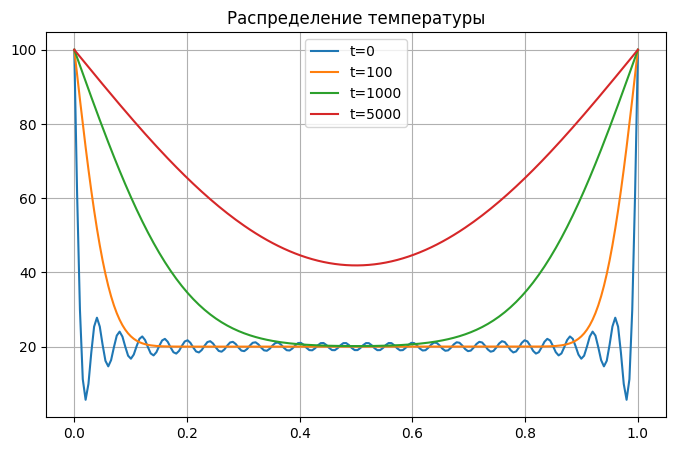

In [32]:
import matplotlib.pyplot as plt

x_vals = np.linspace(0, 1, 200)
times = [0, 100, 1000, 5000]

plt.figure(figsize=(8,5))

for t_val in times:
    plt.plot(x_vals, u_func(x_vals, t_val), label=f"t={t_val}")

plt.legend()
plt.grid()
plt.title("Распределение температуры")

plt.show()

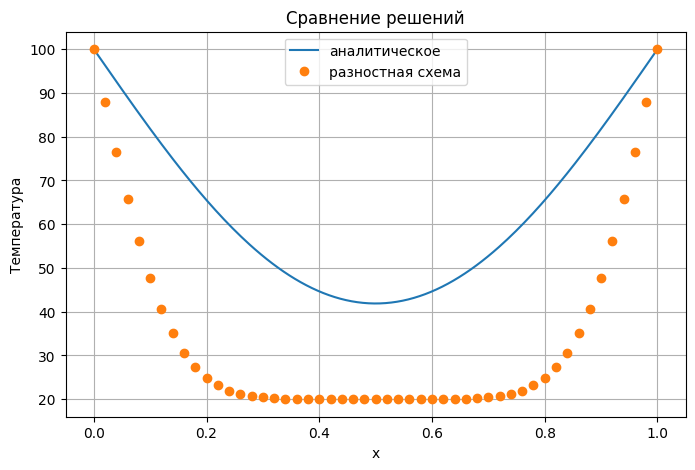

In [37]:
plt.figure(figsize=(8,5))

plt.plot(x_vals, u_func(x_vals, 5000), label="аналитическое")
plt.plot(x_num, u, 'o', label="разностная схема")

plt.xlabel("x")
plt.ylabel("Температура")
plt.title("Сравнение решений")
plt.legend()
plt.grid()

plt.show()